Accuracy: 80.83%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         2
           2       0.33      0.67      0.44         3
           3       1.00      0.00      0.00         5
           4       1.00      0.50      0.67         4
           5       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4
           8       1.00      0.67      0.80         3
           9       1.00      0.75      0.86         4
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         1
          12       0.40      1.00      0.57         4
          13       1.00      0.80      0.89         5
          14       1.00      0.40      0.57         5
          15       0.67      1.00      0.80         2
          16       1.00      0.67      0.80         3
          17       1.00      1.00      1

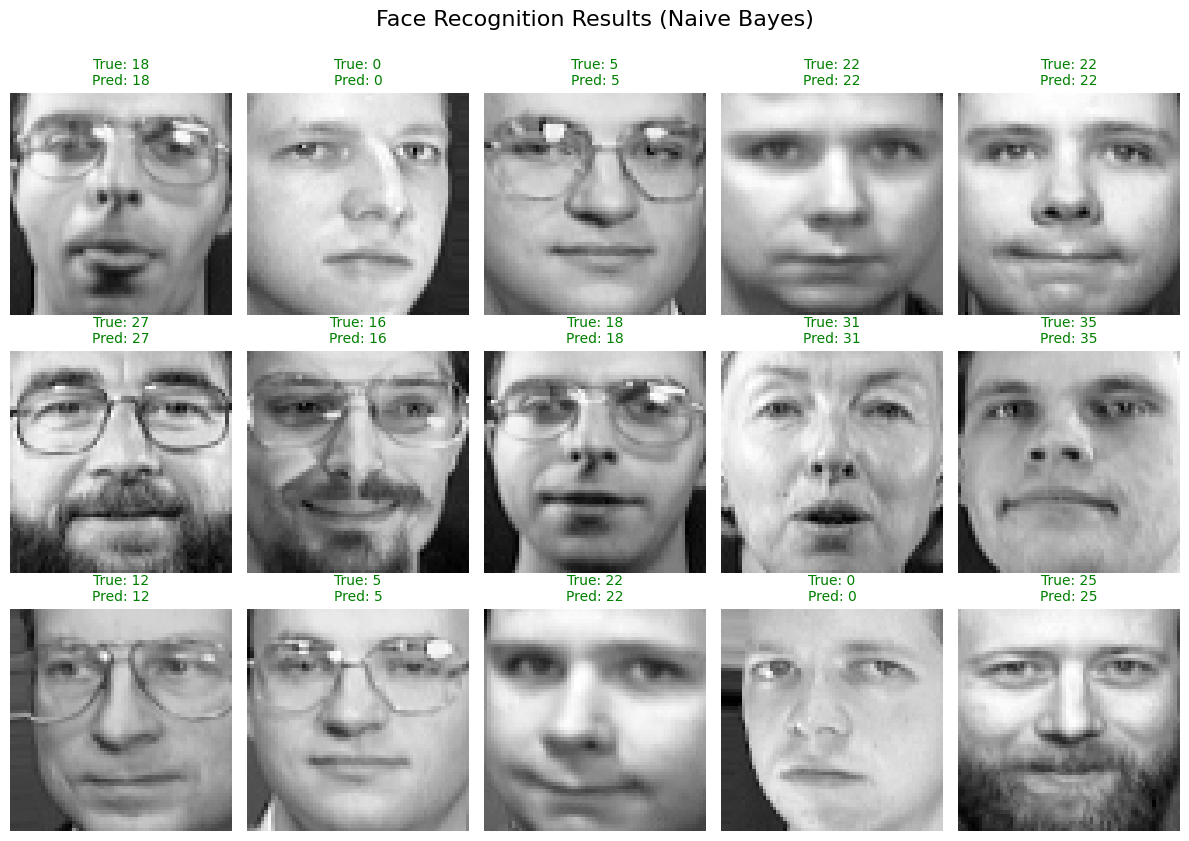

In [1]:
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Load the dataset (Built-in Olivetti Faces)
data = fetch_olivetti_faces(shuffle=True, random_state=42)
X = data.data
y = data.target

# 2. Split the data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and train the Gaussian Naive Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 4. Make predictions and evaluate accuracy
y_pred = gnb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# 5. Print classification metrics
print("\nClassification Report:")
# zero_division=1 prevents errors if a certain face isn't predicted at all
print(classification_report(y_test, y_pred, zero_division=1))

# 6. Cross-validation (Checks if the model is consistent)
cross_val_accuracy = cross_val_score(gnb, X, y, cv=5)
print(f'\nCross-validation accuracy (Average): {cross_val_accuracy.mean() * 100:.2f}%')

# 7. Visualize the results (Fixed Indentation and Loop)
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for i, ax in enumerate(axes.ravel()):
    # Show the image
    ax.imshow(X_test[i].reshape(64, 64), cmap=plt.cm.gray)
    
    # Set title with True label and Predicted label
    title_color = "green" if y_test[i] == y_pred[i] else "red"
    ax.set_title(f"True: {y_test[i]}\nPred: {y_pred[i]}", color=title_color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Face Recognition Results (Naive Bayes)", fontsize=16, y=1.05)
plt.show()